# 公共データの取得と前処理 — Sentinel-2 / Sentinel-1 と e-Stat

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/tutorials/02_public_data_gee.ipynb)

> **Private リポジトリの注意:** このリポジトリは Private 設定のため、上のバッジから直接開けない場合があります。
> その場合は [Google Colab](https://colab.research.google.com/) で「ファイル → ノートブックを開く → GitHub → プライベート リポジトリを含める」から開いてください。

本ノートは **最終課題「相馬市・南相馬市における作付／休耕の変動分析」** の土台となる、
公共データ（衛星＋政府統計）を手に入れて前処理までを行うハンズオンです。

### 学習目標
- 衛星・政府統計それぞれの「どこから」「どうやって」データを取るかを体験する
- Sentinel-2（光学: NDVI）と Sentinel-1（SAR: 偏波）で同じ場所の農地を見比べられるようになる
- 作付／休耕を調べるための「サンプル農地ポリゴン」を作れるようになる
- 衛星の結果を e-Stat の統計値でクロスチェックできるようになる

### 使うデータ
| データ | 提供元 | 何のために使うか |
|---|---|---|
| Sentinel-2 L2A（反射率） | ESA / GEE | NDVI による植生・作付の把握 |
| Sentinel-1 GRD（SAR） | ESA / GEE | VH偏波による水田の湛水・田植え期の把握 |
| 耕地面積統計（作物統計調査・市町村別データ） | e-Stat（政府統計の総合窓口） | 衛星結果と突き合わせる地上データ |

---

---
## 0. 準備とセットアップ

必要なライブラリをインストールし、Google Earth Engine (GEE) に接続します。
GEE は無料のアカウントがあれば誰でも使えます（読み取りだけで、お金はかかりません）。

1. [Google Earth Engine の登録](https://earthengine.google.com/signup/)（初回のみ）
2. 下のセルを実行 → ブラウザが開くので認証を許可
3. プロジェクトIDを尋ねられたら、自分の GEE プロジェクトID（例: `ee-yourproject`）を入力
   （演習用に配布されたIDがある場合はそれを使う）


In [2]:
# 必要なライブラリのインストール（Colab / ローカルの Jupyter どちらでも同じ）
!pip install -q geemap earthengine-api pandas matplotlib requests openpyxl japanize-matplotlib


In [3]:
import ee
import geemap
import pandas as pd
import numpy as np
import os
import sys
import getpass
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # あれば使う（無くても env.setup_font() が日本語対応）
except ImportError:
    japanize_matplotlib = None  # 未インストールでも続行（ローカルはシステムフォントで表示）

# ---- GEE の認証・初期化（Colab / ローカル両対応） ----
# ローカルで認証済みならブラウザは開かず、既存の認証を使います。
try:
    from env import gee_setup
    gee_setup()
except ImportError:
    # env.py 未アップロード時のフォールバック（従来のコード）
    GEE_PROJECT = os.environ.get('GEE_PROJECT')
    if not GEE_PROJECT:
        GEE_PROJECT = getpass.getpass('GEE プロジェクトIDを入力してください (例: ee-yourproject): ')
    print(f'GEE project: {GEE_PROJECT}')
    ee.Authenticate()
    print('GEE 初期化中...')
    try:
        ee.Initialize(project=GEE_PROJECT)
        print('GEE 初期化成功')
    except Exception as e:
        print(f'GEE 初期化エラー: {e}')
        print('プロジェクトIDが正しいか確認してください。')

print("GEE 接続 OK")


GEE 初期化成功（既存の認証を利用）
GEE 接続 OK


In [4]:
# ---- matplotlib 日本語フォント設定（Colab / ローカル / OS 別） ----
try:
    from env import setup_font
    setup_font()
except ImportError:
    # env.py 未アップロード時のフォールバック（従来のコード）
    import matplotlib.font_manager as _fm
    import platform
    _IN_COLAB = 'google.colab' in sys.modules
    print(f'実行環境: {"Google Colab" if _IN_COLAB else "VSCode / ローカル"}')
    if _IN_COLAB:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)
        _fm._load_fontmanager(try_read_cache=False)
    _system = platform.system()
    _jp_candidates = {
        'Darwin': ['Hiragino Sans', 'AppleGothic'],
        'Windows': ['Yu Gothic', 'MS Gothic'],
    }.get(_system, ['Noto Sans CJK JP', 'IPAexGothic'])
    _found = [f for f in _jp_candidates if f in [x.name for x in _fm.fontManager.ttflist]]
    if _found:
        plt.rcParams['font.sans-serif'] = _found
    else:
        _alt = sorted(set(x.name for x in _fm.fontManager.ttflist
                           if any(c in x.name for c in ['Noto', 'IPA', 'Gothic', 'Yu', 'Hiragino'])))
        if _alt:
            plt.rcParams['font.sans-serif'] = _alt
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False


実行環境: VSCode / ローカル ／ 日本語フォント: ['Yu Gothic', 'MS Gothic']


---
## 1. 対象地域の設定（解析範囲 ROI）

最終課題の対象は **相馬市・南相馬市** です。`resources/osm-guide.md` で整理した参照座標を
使って、次の 2 つの解析範囲を置きます。

| エリア | bbox (minLon, minLat, maxLon, maxLat) | 特記 |
|---|---|---|
| 相馬市 | (140.90, 37.77, 141.01, 37.83) | 松川浦（潟湖）が東部、宇多川が南流 |
| 南相馬市 東側クラスタ | (140.99, 37.60, 141.04, 37.66) | 原発事故の避難指示区域（葛尾村川内・浪江町大堀）を含む |

参考: 新田川河口 (37.641, 141.020) ／ 北原川の農地 (37.605–37.615, 141.0–141.05) ／ ため池 (37.612, 141.008)


In [5]:
# 解析対象の範囲を設定する
roi_soma   = ee.Geometry.Rectangle([140.90, 37.77, 141.01, 37.83])   # 相馬市
roi_minami = ee.Geometry.Rectangle([140.99, 37.60, 141.04, 37.66])   # 南相馬市 東側クラスタ
roi = roi_soma.union(roi_minami)

# 地図に表示
m = geemap.Map(center=[37.72, 140.98], zoom=10)
m.add_layer(ee.Image().paint(roi_soma,   1, 2), {}, 'ROI 相馬市')
m.add_layer(ee.Image().paint(roi_minami, 2, 2), {}, 'ROI 南相馬市東側')
m

Map(center=[37.72, 140.98], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## 2. サンプル農地ポリゴンを作る

作付／休耕を比較するため、OSM（OpenStreetMap）の参照座標をもとに、農地らしい場所に
**四角いサンプルポリゴン** を作ります。まず矩形で置き、あとで真色画像で本当に農地か
どうかを目視確認しながら調整します。

> **POINT:** 精密な境界線は最初から必要ありません。矩形で置いて画像上で確認しながら
> 調整するのが、衛星リモートセンシングの基本の流れです。


In [6]:
# サンプル農地ポリゴン（矩形）
# 相馬市: 松川浦（潟湖, 140.978付近）を避け、その西側・北側の平野部
soma_farm    = ee.Feature(ee.Geometry.Rectangle([140.948, 37.787, 140.958, 37.797]), {'label': '相馬 松川浦西北'})
soma_farm2   = ee.Feature(ee.Geometry.Rectangle([140.960, 37.795, 140.968, 37.803]), {'label': '相馬 松川浦北'})

# 南相馬市 東側クラスタ: 新田川河口(141.020)の北西と、北原川(140.996-141.006)付近
minami_farm  = ee.Feature(ee.Geometry.Rectangle([141.000, 37.636, 141.010, 37.644]), {'label': '南相馬 河口北西'})
minami_farm2 = ee.Feature(ee.Geometry.Rectangle([140.996, 37.606, 141.006, 37.614]), {'label': '南相馬 北原川'})

samples = ee.FeatureCollection([soma_farm, soma_farm2, minami_farm, minami_farm2])

print('ポリゴン数:', samples.size().getInfo())
# ポリゴン名と中心座標を確認（FeatureCollection に geometries() は無いので getInfo() を直接使う）
for feat in samples.getInfo()['features']:
    geom = feat['geometry']
    xs = [p[0] for p in geom['coordinates'][0]]
    ys = [p[1] for p in geom['coordinates'][0]]
    print(feat['properties']['label'],
          f"中心=({sum(xs)/len(xs):.4f}, {sum(ys)/len(ys):.4f})")

ポリゴン数: 4
相馬 松川浦西北 中心=(140.9520, 37.7910)
相馬 松川浦北 中心=(140.9632, 37.7982)
南相馬 河口北西 中心=(141.0040, 37.6392)
南相馬 北原川 中心=(141.0000, 37.6092)


---
## 3. Sentinel-2（光学）で NDVI を見る

Sentinel-2 は光学衛星で、**赤色 (B4)** と **近赤外 (B8)** の反射率から
植生の元気さを示す **NDVI = (B8 - B4) / (B8 + B4)** を計算できます。
水稲が育つほど NDVI は高くなります。

まず **最新シーズン（2025年）** の1年で、作付／休耕の「見た目」の違いを確認します。
雲の少ないシーンだけを使います。期間を長く比べるのはセクション5で行います。


In [7]:
# Sentinel-2 (L2A: 大気補正済み反射率) を範囲・期間で取得（まず2025年の1年分）
S2_YEAR = 2025

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate(f'{S2_YEAR}-01-01', f'{S2_YEAR}-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

print('Scene 数:', s2.size().getInfo())

# NDVI を計算して ImageCollection に追加
def add_ndvi(img):
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img.addBands(ndvi)

s2_ndvi = s2.map(add_ndvi)

Scene 数: 78


In [8]:
# 作付期（5〜9月）の平均 NDVI を合成し、地図に表示
s2_summer = s2_ndvi.filterDate(f'{S2_YEAR}-05-01', f'{S2_YEAR}-09-30').select('NDVI')
ndvi_mean = s2_summer.mean()

# 真色（RGB）画像も合わせて表示し、サンプルポリゴンが農地かを目視確認する
m1 = geemap.Map(center=[37.70, 140.99], zoom=10)
rgb = (s2.filterDate(f'{S2_YEAR}-06-01', f'{S2_YEAR}-07-31').median()
         .select(['B4', 'B3', 'B2']).visualize(min=0, max=3000))
m1.add_layer(rgb, {}, f'真色 RGB ({S2_YEAR}年夏)')
m1.add_layer(ndvi_mean.visualize(min=-0.2, max=0.8, palette=['brown', 'white', 'green']),
             {}, 'NDVI 平均 (5-9月)')
m1.add_layer(ee.Image().paint(samples, 0, 2), {}, 'サンプル農地')
m1

Map(center=[37.7, 140.99], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 4. Sentinel-1（SAR）で水田の湛水を見る

Sentinel-1 は **SAR（合成開口レーダー）** で、光学と違い雲があっても観測できます。
特に **VH 偏波**（送信 Vertical・受信 Horizontal）の後方散乱は、水面では低く、
稲が育つと高くなるため、**水田の田植え・湛水の時期**を検出するのに使えます。

作付水田では「4〜5月の田植え（湛水 → VH 低下）→ 夏の稲（VH 上昇）」という季節変化が、
休耕田では水位変化が小さい、つまり **変化が小さく** なります。


In [9]:
# Sentinel-1 GRD (VH偏波) を取得（まず2025年の1年分）
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(roi)
        .filterDate(f'{S2_YEAR}-01-01', f'{S2_YEAR}-12-31')
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')))

print('Scene 数:', s1.size().getInfo())

# 年度を通した平均 VH
# ※ COPERNICUS/S1_GRD の VH は既に dB 値。10*log10 を二重に適用すると NaN になるので変換しない
vh_annual = s1.select('VH').mean()

m2 = geemap.Map(center=[37.70, 140.99], zoom=10)
m2.add_layer(vh_annual.visualize(min=-18, max=0, palette=['black', 'gray', 'white']),
             {}, 'VH 年間平均 (dB)')
m2.add_layer(ee.Image().paint(samples, 0, 2), {}, 'サンプル農地')
m2

Scene 数: 30


Map(center=[37.7, 140.99], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 5. サンプル農地ごとの時系列を抽出する（複数年）

1年だけでなく、**2021〜2025年の5年分** を「年×月」で抽出して比べます。
作付している年と休耕している年で、カーブがどう違うかを観察してみましょう。

> **POINT:** 作付／休耕の分析では「1年の見た目」ではなく、**年の変化** が重要です。
> 休耕は「毎年同じ」ではなく、年によって作付と休耕が入れ替わることがあります。


In [10]:
# 時系列抽出用に、2021〜2025年全体のコレクションを用意する
# （セクション3/4で作った s2_ndvi・s1 は2025年のみなので、ここで全期間を取る）
s2_ndvi_all = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate('2021-01-01', '2025-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(add_ndvi))

s1_all = (ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(roi)
        .filterDate('2021-01-01', '2025-12-31')
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')))

# VH（既にdB値）を VH_db という名前のバンドとして持つコレクションを作る
# ※ S1_GRD の VH は既に dB。10*log10 を二重に適用すると NaN になるので変換しない
s1_db_all = s1_all.map(lambda img: img.select('VH').rename('VH_db'))

print('S2 all:', s2_ndvi_all.size().getInfo(), '/ S1 all:', s1_db_all.size().getInfo())

# 対象年と月（5年 × 12ヶ月）
years  = [2021, 2022, 2023, 2024, 2025]
months = list(range(1, 13))

S2 all: 336 / S1 all: 151


### 5-1 まず 1年分で速試し（2025年）

全期間を一気にやると時間がかかるので、まず **2025年だけ**で動くことを確認します。


In [11]:
# 1年分（2025年）で試す
def extract_timeseries(year, m_list):
    recs = []
    for m in m_list:
        d0 = ee.Date.fromYMD(year, m, 1)
        d1 = d0.advance(1, 'month')

        # 月ごとのコレクション（データが無い月は .mean() がバンド無し画像になるため、スキップする）
        ndvi_coll = s2_ndvi_all.select('NDVI').filterDate(d0, d1)
        vh_coll   = s1_db_all.select('VH_db').filterDate(d0, d1)
        if ndvi_coll.size().getInfo() == 0 or vh_coll.size().getInfo() == 0:
            continue

        ndvi_img = ndvi_coll.mean().rename('NDVI')
        vh_img   = vh_coll.mean().rename('VH_db')
        img      = ee.Image.cat([ndvi_img, vh_img]).float()

        fc = img.reduceRegions(
            collection=samples,
            reducer=ee.Reducer.mean(),
            scale=100,
            maxPixelsPerRegion=1e9)

        for feat in fc.getInfo()['features']:
            p = feat['properties']
            recs.append({'year': year, 'month': m,
                         'polygon': p.get('label'),
                         'NDVI': p.get('NDVI'),
                         'VH_db': p.get('VH_db')})
    return pd.DataFrame(recs)

df_test = extract_timeseries(2025, months)
df_test

,year,month,polygon,NDVI,VH_db
0,2025,1,相馬 松川浦西北,0.281261,-20.768463
1,2025,1,相馬 松川浦北,0.219010,-21.094332
2,2025,1,南相馬 河口北西,0.248710,-20.673955
3,2025,1,南相馬 北原川,0.311386,-17.574890
4,2025,2,相馬 松川浦西北,0.204309,-21.141662
5,2025,2,相馬 松川浦北,0.171727,-21.822338
6,2025,2,南相馬 河口北西,0.218972,-21.587828
7,2025,2,南相馬 北原川,0.266919,-17.752473
8,2025,3,相馬 松川浦西北,0.264149,-19.845070
9,2025,3,相馬 松川浦北,0.189377,-19.399600


### 5-2 全期間（2021〜2025年）で抽出

無事動けば、全期間で抽出します。実行に数分かかります。


In [12]:
# 全期間（2021〜2025年）で抽出
df = pd.concat([extract_timeseries(y, months) for y in years], ignore_index=True)
print('レコード数:', len(df))
df

レコード数: 228


,year,month,polygon,NDVI,VH_db
0,2021,1,相馬 松川浦西北,0.235158,-19.661256
1,2021,1,相馬 松川浦北,0.174505,-21.934698
2,2021,1,南相馬 河口北西,0.241214,-20.529190
3,2021,1,南相馬 北原川,0.293362,-17.277889
4,2021,2,相馬 松川浦西北,0.156417,-20.161768
...,...,...,...,...,...
223,2025,11,南相馬 北原川,0.411420,-16.035578
224,2025,12,相馬 松川浦西北,0.317313,-19.327055
225,2025,12,相馬 松川浦北,0.236955,-20.064714
226,2025,12,南相馬 河口北西,0.249998,-19.314554


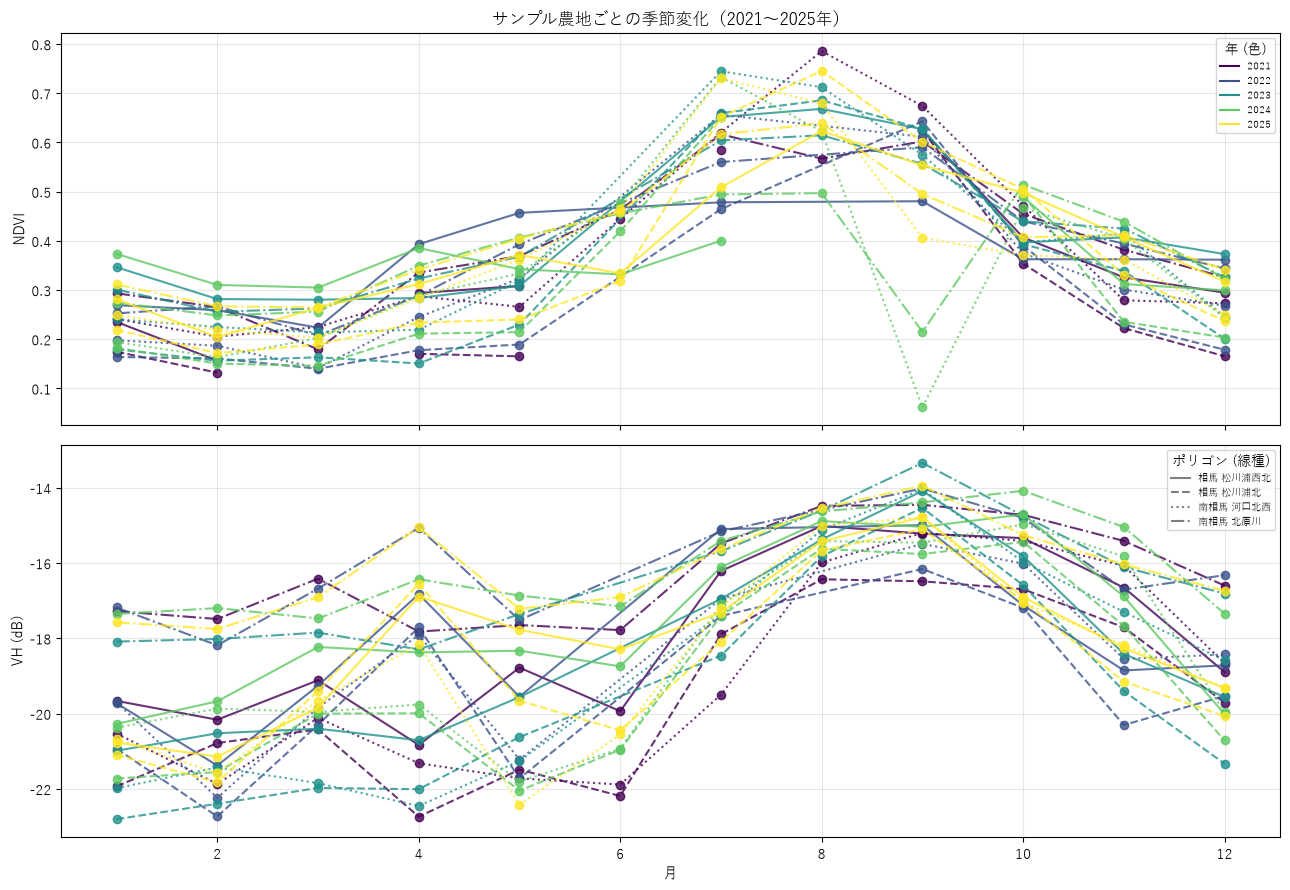

In [13]:
# 時系列をプロット（年 = 色, ポリゴン = 線種）
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
styles = ['-', '--', ':', '-.']

for y, c in zip(years, colors):
    for i, poly in enumerate(df['polygon'].unique()):
        sy = df[(df['polygon'] == poly) & (df['year'] == y)].sort_values('month')
        axes[0].plot(sy['month'], pd.to_numeric(sy['NDVI']),
                     color=c, linestyle=styles[i], marker='o', alpha=0.8)
        axes[1].plot(sy['month'], pd.to_numeric(sy['VH_db']),
                     color=c, linestyle=styles[i], marker='o', alpha=0.8)

# 凡例（年 = 色）を NDVI 軸に、ポリゴン（線種）を VH 軸に分ける
for y, c in zip(years, colors):
    axes[0].plot([], [], color=c, label=str(y))
axes[0].legend(title='年 (色)', fontsize=7, loc='upper right')

for i, poly in enumerate(df['polygon'].unique()):
    axes[1].plot([], [], color='gray', linestyle=styles[i], label=poly)
axes[1].legend(title='ポリゴン (線種)', fontsize=7, loc='upper right')

axes[0].set_ylabel('NDVI')
axes[0].grid(alpha=0.3)
axes[0].set_title('サンプル農地ごとの季節変化（2021〜2025年）')

axes[1].set_ylabel('VH (dB)')
axes[1].set_xlabel('月')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 年間の「作付度」を読み取る表を作る
# 5〜9月（作付期）の平均 NDVI が高い年 = 作付が盛んな年
df['NDVI']  = pd.to_numeric(df['NDVI'])
df['VH_db'] = pd.to_numeric(df['VH_db'])

summer = df[df['month'].between(5, 9)].groupby(['polygon', 'year'])['NDVI'].mean().unstack()
print('作付期(5-9月)平均 NDVI: 高いほど作付が盛ん')
summer

作付期(5-9月)平均 NDVI: 高いほど作付が盛ん


year,2021,2022,2023,2024,2025
polygon,,,,,
南相馬 北原川,0.523657,0.514454,0.535734,0.413839,0.522876
南相馬 河口北西,0.558144,0.530438,0.587686,0.445645,0.528785
相馬 松川浦北,0.482817,0.432250,0.550728,0.428221,0.511425
相馬 松川浦西北,0.505801,0.471970,0.563904,0.358210,0.478167


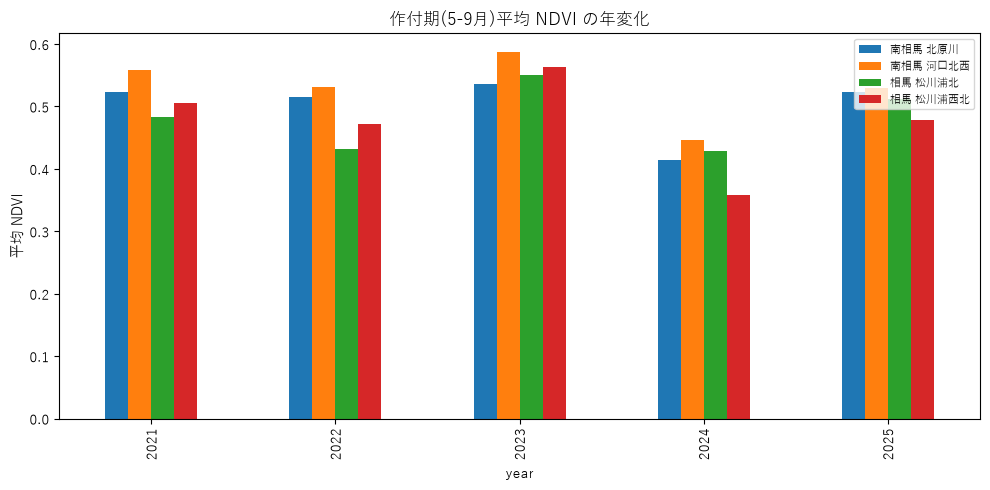

In [15]:
# 作付期の平均 NDVI を年で並べてバープロット
summer.T.plot(kind='bar', figsize=(10, 5))
plt.title('作付期(5-9月)平均 NDVI の年変化')
plt.ylabel('平均 NDVI')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. 政府統計でクロスチェック（e-Stat）

衛星だけで判断せず、**国の公的統計** と突き合わせる習慣をつけましょう。
ここでは e-Stat（政府統計の総合窓口）が公開している **作物統計調査 市町村別データ**
（農林水産省 面積調査 による **耕地面積**）をプログラムから取得します。

対象は令和6年（2024年）産・福島県の「耕地面積」統計表で、相馬市・南相馬市の値は次の通りです。

- 相馬市: 耕地面積 **3,260 ha**（田 2,630 / 畑 632）※2024年値
- 南相馬市: 耕地面積 **6,910 ha**（田 5,690 / 畑 1,220）※2024年値

> **POINT:** e-Stat の統計表ファイルは **statInfId** というID付きURLで直接ダウンロードできます
> （アプリ登録なし・無料）。ただしファイル形式は昔ながらの **.xls** なので、Python で読むには
> `xlrd` ライブラリが必要です。
>
> **POINT:** 通信が無くても動くよう、下のセルには「つながらない場合」のフォールバック値を
> 埋め込んであります。ただしレポートでは **必ず出典（URL・更新年）を明記** してください。
> なお、過去に「わがマチ・わがムラ」の CSV を使う方式もありましたが、Colab からは
> 接続できない（403）ことがあるため、本ノートでは e-Stat を採用しています。


In [16]:
%pip install -q xlrd==1.2.0

Note: you may need to restart the kernel to use updated packages.


In [17]:
# e-Stat の「作物統計調査 市町村別データ」を直接ダウンロード
#   対象: 令和6年(2024)産・福島県「耕地面積」(面積調査)
#   ファイルURL: stat-search/file-download?statInfId=000040250161&fileKind=0
%pip install -q xlrd==1.2.0   # 昔の .xls を読むためのライブラリ

import io, urllib.request, xlrd, pandas as pd

STAT_URL = "https://www.e-stat.go.jp/stat-search/file-download?statInfId=000040250161&fileKind=0"

def fetch_cultivated_area(city_name, fallback):
    try:
        req = urllib.request.Request(STAT_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=30) as res:
            xls_bytes = res.read()
        wb = xlrd.open_workbook(file_contents=xls_bytes)
        sh = wb.sheet_by_index(0)
        # 行構造: 0〜3=タイトル, 4〜7=見出し, 8以降=市町村ごとのデータ
        # 列: 1=市町村ｺｰﾄﾞ, 2=市町村名, 3=耕地面積, 4=田, 5=田本地, 6=畑 [ha]
        for r in range(8, sh.nrows):
            if str(sh.cell_value(r, 2)) == city_name:
                return pd.DataFrame({'統計項目': ['耕地面積', '田耕地面積', '畑耕地面積'],
                                     '年': 2024, city_name: [sh.cell_value(r, 3),
                                                              sh.cell_value(r, 4),
                                                              sh.cell_value(r, 6)]})
        raise ValueError(f"市町村名 {city_name} が見つかりません")
    except Exception as e:
        print(f"  [fallback] {city_name}: 取得できず ({e})")
        return pd.DataFrame({'統計項目': ['耕地面積', '田耕地面積', '畑耕地面積'],
                             '年': 2024, city_name: fallback})

soma   = fetch_cultivated_area('相馬市',     [3260, 2630, 632])
minami = fetch_cultivated_area('南相馬市',   [6910, 5690, 1220])

summary = soma.merge(minami, on=['統計項目', '年'], how='outer')
summary

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


,統計項目,年,相馬市,南相馬市
0,田耕地面積,2024,2630.0,5690.0
1,畑耕地面積,2024,632.0,1220.0
2,耕地面積,2024,3260.0,6910.0


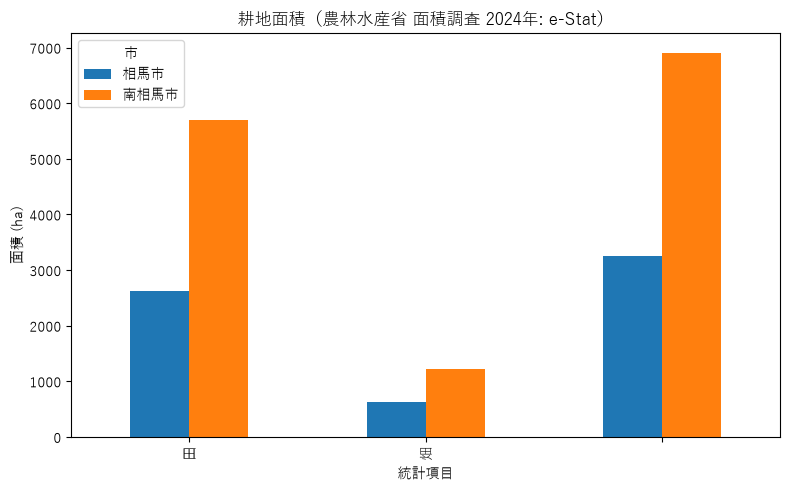

In [18]:
# 2市の耕地面積を可視化
plot_df = summary.copy()
plot_df['統計項目'] = plot_df['統計項目'].str.replace('耕地面積', '', regex=False)
plot_df = plot_df.set_index('統計項目')
for c in plot_df.columns:
    if c != '年':
        plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

plot_df[['相馬市', '南相馬市']].plot(kind='bar', figsize=(8, 5))
plt.title('耕地面積（農林水産省 面積調査 2024年: e-Stat）')
plt.ylabel('面積 (ha)')
plt.legend(title='市')
plt.tight_layout()
plt.show()

---
## まとめと次への一歩

- Sentinel-2 の **NDVI** と Sentinel-1 の **VH** を同じポリゴンで抽出すると、
  作付／休耕の季節パターンの違いが見えるようになる。
- **複数年（2021〜2025）で比べると**、作付期（5〜9月）の NDVI が高い年と低い年が
  読み取れ、「どの年は作付が盛んだったか」という **変化** を把握できる。
- サンプルポリゴンを「その場で」（まず矩形で、必要なら編集で）置き、
  真色画像で目視確認する、という流れが基本。
- 衛星の結果は **e-Stat / 行政の統計** と必ずクロスチェックし、出典を明記する。

**最終課題へ進むときのヒント**
1. 本ノートの「作付期平均 NDVI」の表を、年ごとに並べて **休耕（低い年）を検出** する
2. 次はポリゴン単位でなく **エリア全体をピクセル単位で判定** し、作付／休耕の
   **面積（ha）を年ごとに集計** すると、変動を定量的に示せる
3. 判別の確認には、水稲が作付けられている「水田区分」（農林水産省の農地台帳等）や
   Dynamic World（土地利用分類）を組み合わせると説得力が増す

---
*出典: Sentinel-2 L2A / Sentinel-1 GRD（Google Earth Engine 経由）・
e-Stat 作物統計調査 市町村別データ（令和6年産・耕地面積）*
